In [80]:
import numpy as np
import math 
import matplotlib.pyplot as plt
import csv
from csv import writer
import matplotlib.ticker as mticker
from matplotlib.ticker import MaxNLocator

In [116]:
#filename='lakeshore_log_2025-01-01T18-41-11'
#filename1='temperature_log_2025-01-01T18-41-11'
#filename2='lakeshore_log_2025-01-25T17-26-16'
#filename3='temperature_log_2025-01-25T17-26-16'
filename2='lakeshore_log_2025-02-07T10-58-07'
filename3='temperature_log_2025-02-07T10-58-07'

In [117]:
# Lakeshore
data_temp_1 = np.loadtxt(filename2+".txt", usecols=1, skiprows=4, dtype='float',delimiter=",") 
data_temp_2 = np.loadtxt(filename2+".txt", usecols=2, skiprows=4, dtype='float',delimiter=",") 
data_temp_3 = np.loadtxt(filename2+".txt", usecols=3, skiprows=4, dtype='float',delimiter=",")
data_date =  np.loadtxt(filename2+".txt", usecols=0, skiprows=4, dtype='str') 
data_time1 =  np.loadtxt(filename2+".txt", usecols=0, skiprows=4, dtype='str',delimiter=",") 
data_time=np.empty(len(data_time1),dtype='U10')
for i in range(len(data_time1)):
    data_time[i]=data_time1[i].split(' ')[1]

In [118]:
data_time_coarse=np.empty(len(data_time1),dtype='U10')

j=0
for i in range(len(data_time)):
    if i%4==0:
        data_time_coarse[j]=data_time[i]
        j+=1

data_time_coarse = np.array([i for i in data_time_coarse if i])

data_temp1_coarse=np.zeros(len(data_time_coarse))
data_temp2_coarse=np.zeros(len(data_time_coarse))
data_temp3_coarse=np.zeros(len(data_time_coarse))

j=0
for i in range(len(data_temp_1)):
    if i%4==0:
        data_temp1_coarse[j]=data_temp_1[i]
        data_temp2_coarse[j]=data_temp_2[i]
        data_temp3_coarse[j]=data_temp_3[i]
        j+=1

data_temp1_coarse = np.array([i for i in data_temp1_coarse if i])
data_temp2_coarse = np.array([i for i in data_temp2_coarse if i])
data_temp3_coarse = np.array([i for i in data_temp3_coarse if i])

In [119]:
data_time_coarse

array(['08:38:48', '08:38:56', '08:39:06', ..., '16:27:50', '16:27:58',
       '16:28:06'], dtype='<U8')

In [120]:
# Cryo cooler
data_temp_cryo = np.loadtxt(filename3+".txt", usecols=1, skiprows=4, dtype='float',delimiter=",") 
data_timestamp_cryo = np.loadtxt(filename3+".txt", usecols=1, skiprows=4, dtype='str') 
data_date_cryo =  np.loadtxt(filename3+".txt", usecols=0, skiprows=4, dtype='str') 

time_stamps_cryo=np.empty(len(data_timestamp_cryo), dtype = 'S20')
for j in range(len(data_timestamp_cryo)):
    count=-1
    for i in data_timestamp_cryo[j]:
        count+=1
        if i==',':
            #print(count)
            time_stamps_cryo[j]=data_timestamp_cryo[j][:count]
        
#data_timestamp[0]

In [121]:
len(data_time)/4

3509.25

In [122]:
len(data_temp_1)

14037

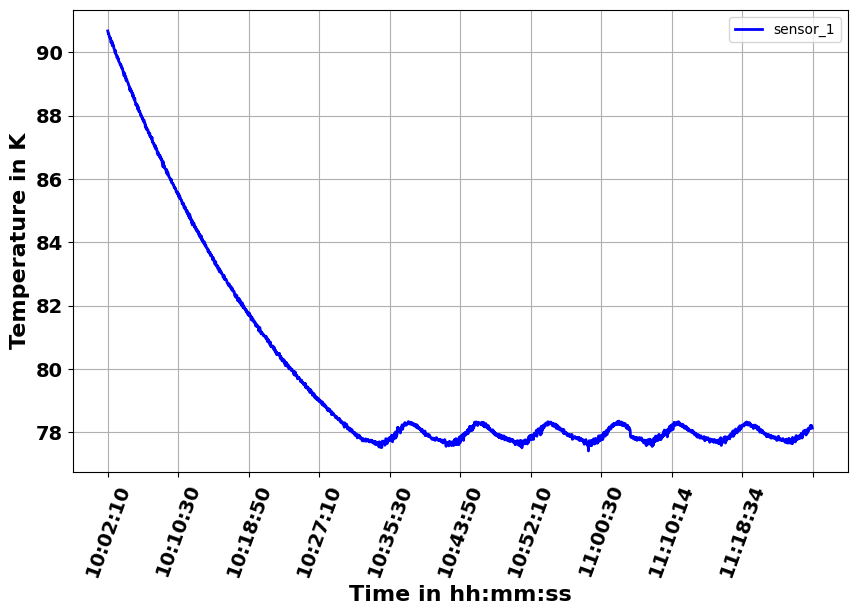

In [142]:
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(data_time[2500:5000],data_temp_2[2500:5000],'b-',linewidth=2,label='sensor_1')
#plt.plot(data_time,data_temp_2,'k-',linewidth=2,label='sensor_2')
#plt.plot(data_time,data_temp_3,'y-',linewidth=2,label='sensor_3')
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
#plt.title("Lakeshore temperature curve 8 feb 2025 run",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()

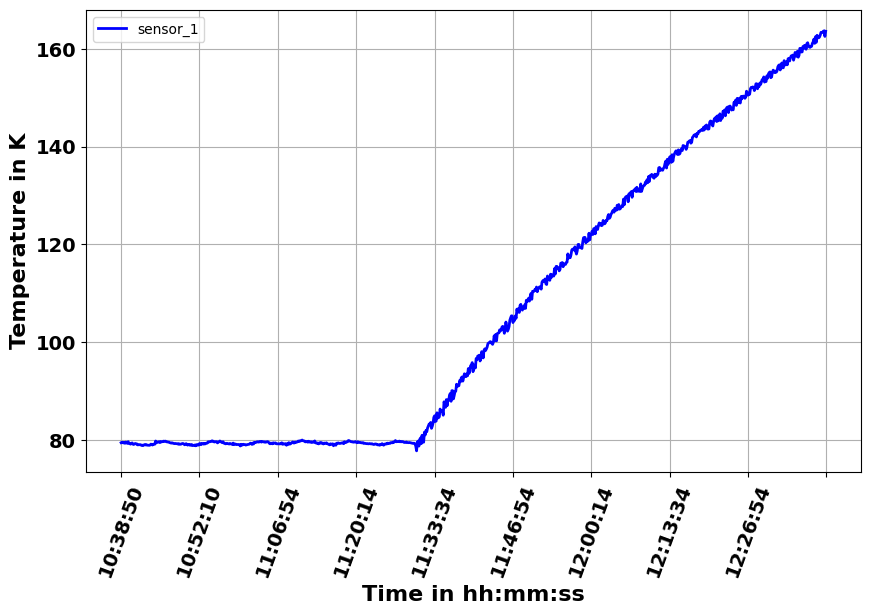

In [126]:
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(data_time_coarse[900:1800],data_temp1_coarse[900:1800],'b-',linewidth=2,label='sensor_1')
#plt.plot(data_time,data_temp_2,'k-',linewidth=2,label='sensor_2')
#plt.plot(data_time,data_temp_3,'y-',linewidth=2,label='sensor_3')
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
#plt.title("Lakeshore temperature curve 8 feb 2025 run",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()

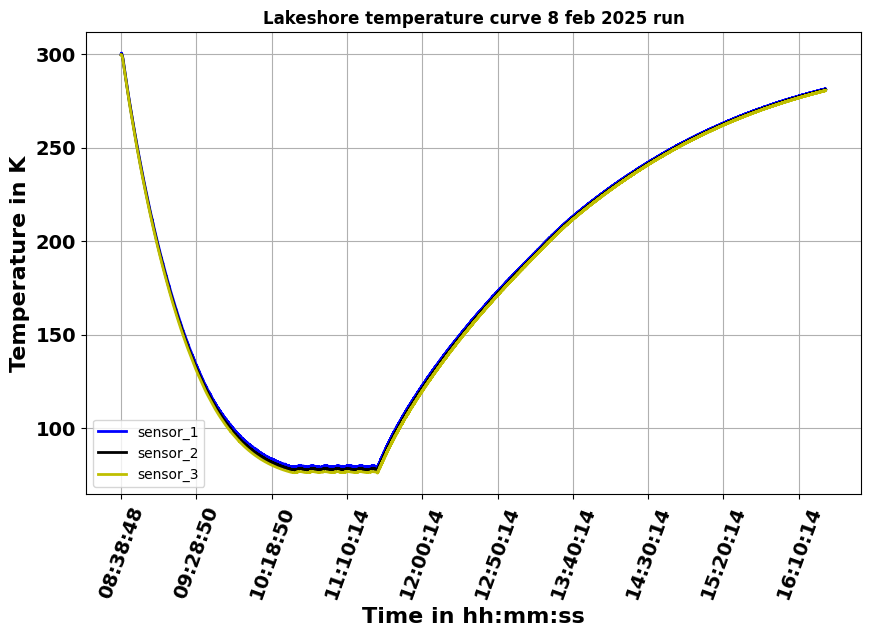

In [127]:
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(data_time,data_temp_1,'b-',linewidth=2,label='sensor_1')
plt.plot(data_time,data_temp_2,'k-',linewidth=2,label='sensor_2')
plt.plot(data_time,data_temp_3,'y-',linewidth=2,label='sensor_3')
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
plt.title("Lakeshore temperature curve 8 feb 2025 run",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()

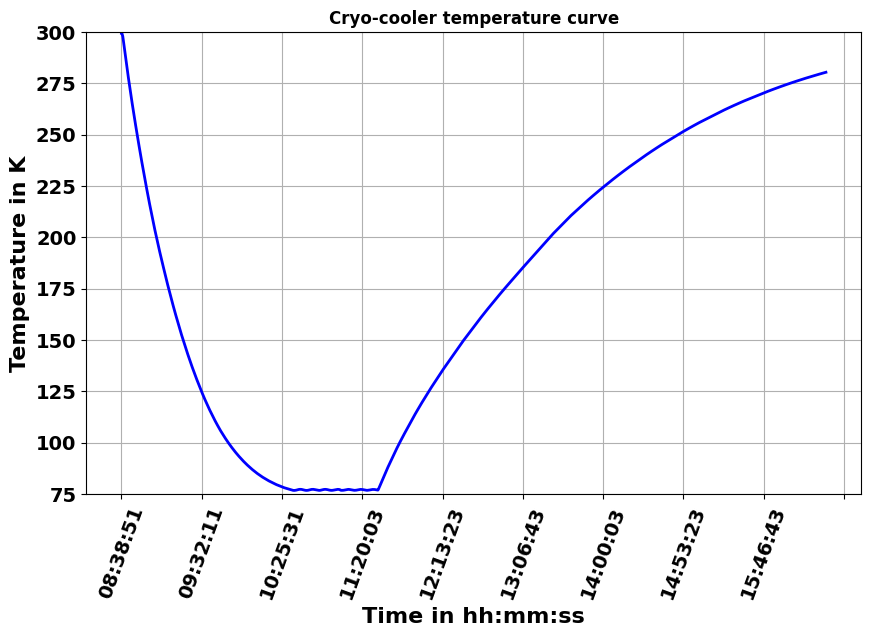

In [128]:
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(time_stamps_cryo,data_temp_cryo,'b-',linewidth=2)
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
plt.title("Cryo-cooler temperature curve",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.ylim(75,300)
plt.grid()
plt.show()

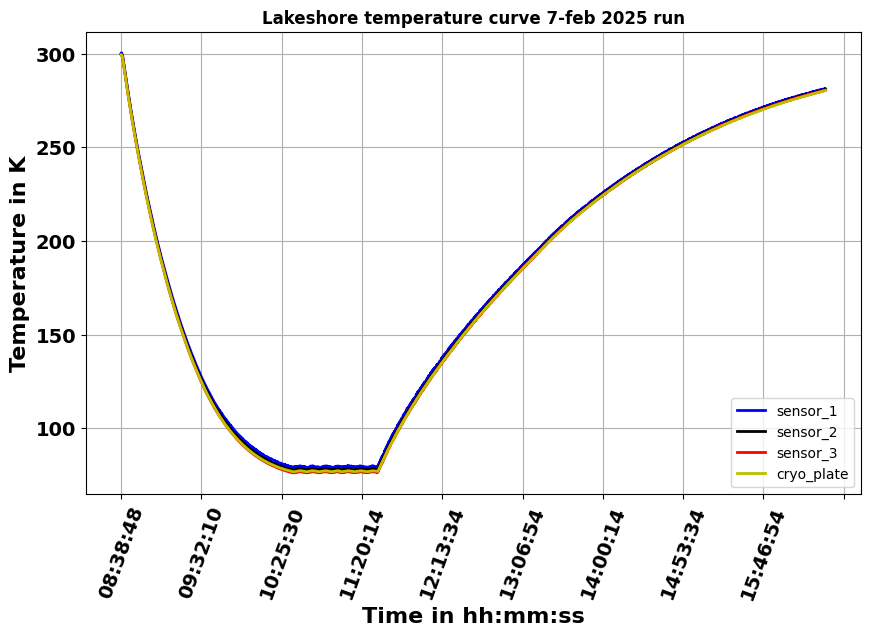

In [132]:
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(data_time_coarse,data_temp1_coarse,'b-',linewidth=2,label='sensor_1')
plt.plot(data_time_coarse,data_temp2_coarse,'k-',linewidth=2,label='sensor_2')
plt.plot(data_time_coarse,data_temp3_coarse,'r-',linewidth=2,label='sensor_3')
plt.plot(data_temp_cryo,'y-',linewidth=2,label='cryo_plate')
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
plt.title("Lakeshore temperature curve 7-feb 2025 run",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()

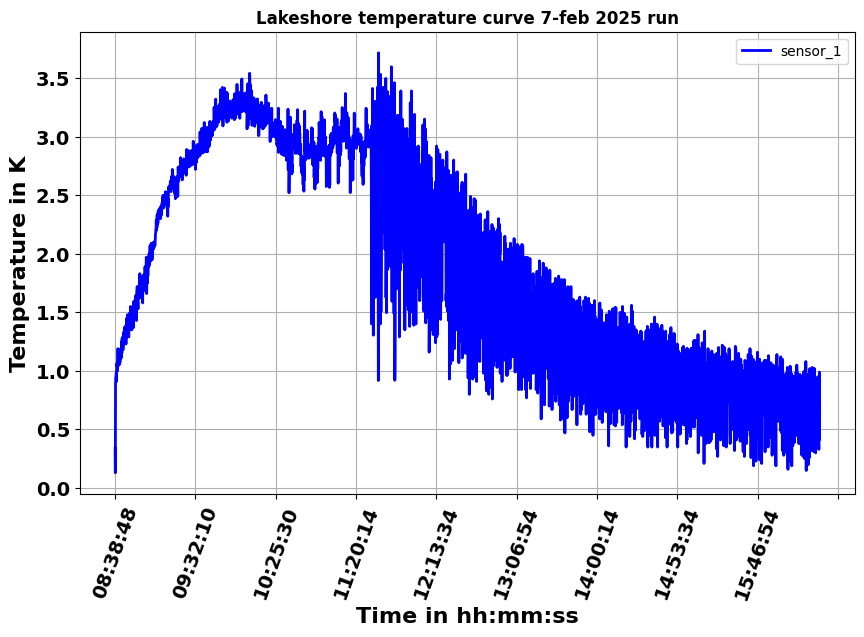

In [141]:
%matplotlib inline 
#%matplotlib qt 
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(data_time_coarse,data_temp1_coarse-data_temp3_coarse,'b-',linewidth=2,label='sensor_1')
#plt.plot(data_time_coarse[:1000],data_temp2_coarse[:1000],'k-',linewidth=2,label='sensor_2')
#plt.plot(data_time_coarse[:1000],data_temp3_coarse[:1000],'r-',linewidth=2,label='sensor_3')
#plt.plot(data_temp_cryo[:1000],'y-',linewidth=2,label='cryo_plate')
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
plt.title("Lakeshore temperature curve 7-feb 2025 run",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()

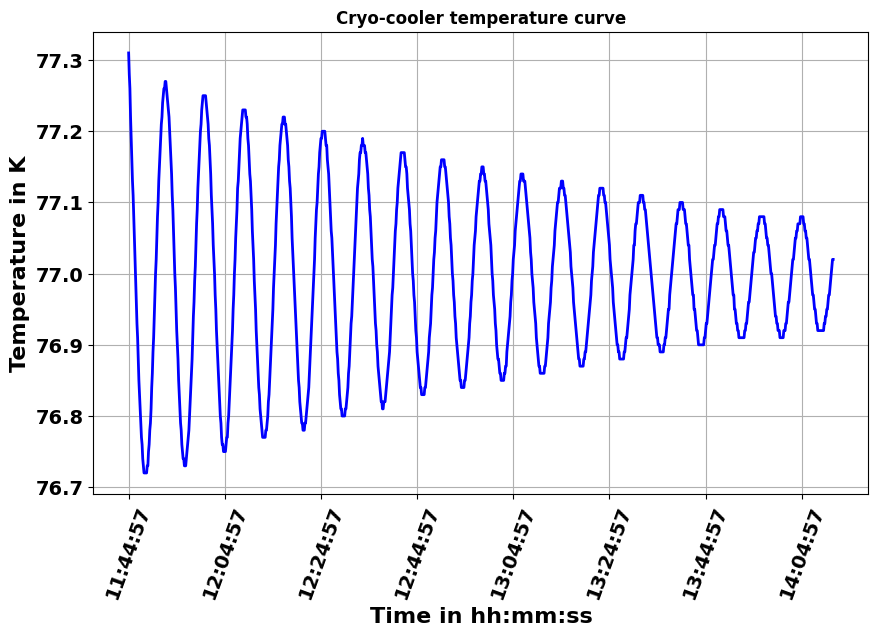

In [115]:
start_cry=900
stop_cry=2000
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(time_stamps_cryo[start_cry:stop_cry],data_temp_cryo[start_cry:stop_cry],'b-',linewidth=2)
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
plt.title("Cryo-cooler temperature curve",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')

plt.grid()
plt.show()

In [32]:
len(time_stamps_cryo)

4929